In [ ]:
#current-working-1D-place-cell-classifier copy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import pickle
from scipy.ndimage import gaussian_filter1d

layer_name = "d3"

with open("trajectory_results.pkl", "rb") as f:
    trajectory_results = pickle.load(f)


In [ ]:
# =====================================
# Analysis Configuration
# =====================================

# Layer to analyse
layer_name = "d3"

# Trajectory to inspect
trajectory_id = 0

# Occupancy bins
num_bins = 80

# Event detection
event_method = "percentile"
event_threshold = 95

# Plotting
normalize_maps = True

# Place Cell Thresholds
event_threshold = 95

spatial_info_threshold = 0.5
sparsity_threshold = 0.4
field_width_threshold = 3

In [77]:
def occupancy_map(position, bins=num_bins, sigma=1):
    """
    Compute normalized occupancy along a 1D track.

    Returns
    -------
    occupancy : ndarray
    edges : ndarray
    """

    counts, edges = np.histogram(position, bins=bins)

    occupancy = counts.astype(float)

    occupancy = gaussian_filter1d(
        occupancy,
        sigma=sigma
    )

    occupancy /= np.sum(occupancy)

    occupancy[occupancy == 0] = np.nan

    return occupancy, edges

In [78]:
def firing_rate_map(
        neuron_activity,
        positions,
        occupancy,
        edges
):

    spike_sum = np.zeros(len(occupancy))

    x = positions[:,0]

    inds = np.digitize(x, edges) - 1
    inds = np.clip(inds, 0, len(occupancy)-1)

    for t in range(len(x)):
        spike_sum[inds[t]] += neuron_activity[t]

    firing_rate = spike_sum / occupancy

    firing_rate[np.isnan(firing_rate)] = 0

    firing_rate = gaussian_filter1d(
        firing_rate,
        sigma=1
    )

    return firing_rate

In [79]:
def spatial_information(rate_map, occupancy):

    occ = occupancy.copy()

    occ /= np.nansum(occ)

    mean_rate = np.nansum(rate_map * occ)

    if mean_rate == 0:
        return 0

    ratio = rate_map / mean_rate

    ratio[ratio <= 0] = 1

    info = np.nansum(
        occ *
        ratio *
        np.log2(ratio)
    )

    return info

In [80]:
def sparsity(rate_map, occupancy):

    occ = occupancy.copy()

    occ /= np.nansum(occ)

    numerator = np.square(
        np.nansum(rate_map * occ)
    )

    denominator = np.nansum(
        occ * rate_map**2
    )

    if denominator == 0:
        return 0

    return numerator / denominator

In [81]:
def detect_events(activity, method="zscore", threshold=1.5):
    """
    Convert continuous activations into spike-like events.

    Parameters
    ----------
    activity : ndarray

    method : str
        "zscore"
        "percentile"

    threshold :
        z-score threshold OR percentile

    Returns
    -------
    events : ndarray
    """

    activity = np.asarray(activity)

    if method == "zscore":

        z = (activity - activity.mean()) / (activity.std() + 1e-10)

        events = np.where(z > threshold, activity, 0)

    elif method == "percentile":

        cutoff = np.percentile(activity, threshold)

        events = np.where(activity > cutoff, activity, 0)

    else:

        raise ValueError("Unknown method")

    return events

In [82]:
def analyze_trajectory(
    trajectory,
    layer_name,
    bins=num_bins,
    event_method="percentile",
    event_threshold=95,
):
    """
    Analyze a single trajectory.

    Returns
    -------
    dict containing:
        positions
        occupancy
        edges
        firing_maps
        metrics
    """

    # ------------------------
    # Extract data
    # ------------------------

    positions = trajectory["pred_position"].reshape(-1, 1)

    activations = np.abs(
        trajectory[layer_name]
    )

    occupancy, edges = occupancy_map(
        positions[:, 0],
        bins=bins
    )

    num_neurons = activations.shape[1]

    firing_maps = []

    metrics = []

    # ------------------------
    # Process every neuron
    # ------------------------

    for neuron in range(num_neurons):

        activity = activations[:, neuron]

        events = detect_events(
            activity,
            method=event_method,
            threshold=event_threshold
        )

        fr = firing_rate_map(
            events,
            positions,
            occupancy,
            edges
        )

        firing_maps.append(fr)

        metrics.append(
            compute_metrics(
                fr,
                occupancy,
                edges
            )
        )

    return {

        "positions": positions,

        "occupancy": occupancy,

        "edges": edges,

        "firing_maps": np.asarray(firing_maps),

        "metrics": metrics
    }

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def plot_neuron_across_trajectories(
    neuron_id,
    results,
    normalize=True,
    figsize=(10,6)
):
    """
    Plot the firing-rate map of ONE neuron across every trajectory.

    Parameters
    ----------
    neuron_id : int
        Neuron index (0-based)

    results : dict
        Output of analyze_dataset()

    normalize : bool
        Normalize each trajectory independently.

    """

    plt.figure(figsize=figsize)

    peak_positions = []

    for traj_id in sorted(results.keys()):

        fr = results[traj_id]["firing_maps"][neuron_id].copy()

        x = (
            results[traj_id]["edges"][:-1]
            + results[traj_id]["edges"][1:]
        ) / 2

        if normalize:

            if fr.max() > 0:
                fr /= fr.max()

        peak = x[np.argmax(fr)]
        peak_positions.append(peak)

        plt.plot(
            x,
            fr,
            linewidth=2,
            label=f"Trajectory {traj_id}"
        )

    plt.xlabel("Position")

    plt.ylabel("Normalized firing rate")

    plt.title(f"Neuron {neuron_id}")

    plt.legend()

    plt.tight_layout()

    plt.show()

    return peak_positions

In [84]:
def compute_metrics(
    firing_map,
    occupancy,
    edges
):
    """
    Compute quantitative metrics for ONE firing-rate map.

    Returns
    -------
    dict
    """

    occ = occupancy.copy()
    occ /= np.nansum(occ)

    mean_rate = np.nansum(
        firing_map * occ
    )

    if mean_rate == 0:

        spatial_info = 0

    else:

        ratio = firing_map / mean_rate

        ratio[ratio <= 0] = 1

        spatial_info = np.nansum(
            occ *
            ratio *
            np.log2(ratio)
        )

    numerator = mean_rate ** 2

    denominator = np.nansum(
        occ * firing_map**2
    )

    sparsity = (
        numerator / denominator
        if denominator > 0
        else 0
    )

    centres = (
        edges[:-1] +
        edges[1:]
    ) / 2

    peak_index = np.argmax(firing_map)

    peak_position = centres[peak_index]

    peak_rate = firing_map[peak_index]

    half_max = peak_rate / 2

    active = firing_map >= half_max

    field_width = np.sum(active)

    return {

        "spatial_info": float(spatial_info),

        "sparsity": float(sparsity),

        "peak_position": float(peak_position),

        "peak_rate": float(peak_rate),

        "field_width": int(field_width)
    }

In [85]:
def analyze_dataset(
    trajectory_results,
    layer_name,
    bins=80,
    event_method="percentile",
    event_threshold=95,
):
    """
    Analyze every trajectory independently.
    """

    results = {}

    for traj_id, trajectory in enumerate(trajectory_results):

        print(
            f"Analyzing trajectory {traj_id+1}/{len(trajectory_results)}"
        )

        results[traj_id] = analyze_trajectory(

            trajectory,

            layer_name,

            bins=bins,

            event_method=event_method,

            event_threshold=event_threshold
        )

    return results

In [86]:
def analyze_trajectory(
    trajectory,
    layer_name,
    bins=80,
    event_method="percentile",
    event_threshold=95,
):

    positions = trajectory["pred_position"].reshape(-1,1)

    activations = np.abs(
        trajectory[layer_name]
    )

    occupancy, edges = occupancy_map(
        positions[:,0],
        bins=bins
    )

    num_neurons = activations.shape[1]

    firing_maps = []

    spatial_info = np.zeros(num_neurons)

    sparsity = np.zeros(num_neurons)

    peak_position = np.zeros(num_neurons)

    peak_rate = np.zeros(num_neurons)

    field_width = np.zeros(num_neurons)

    for neuron in range(num_neurons):

        activity = activations[:,neuron]

        events = detect_events(
            activity,
            method=event_method,
            threshold=event_threshold
        )

        fr = firing_rate_map(
            events,
            positions,
            occupancy,
            edges
        )

        firing_maps.append(fr)

        metric = compute_metrics(
            fr,
            occupancy,
            edges
        )

        spatial_info[neuron] = metric["spatial_info"]
        sparsity[neuron] = metric["sparsity"]
        peak_position[neuron] = metric["peak_position"]
        peak_rate[neuron] = metric["peak_rate"]
        field_width[neuron] = metric["field_width"]

    return {

        "positions": positions,

        "occupancy": occupancy,

        "edges": edges,

        "firing_maps": np.asarray(firing_maps),

        "spatial_info": spatial_info,

        "sparsity": sparsity,

        "peak_position": peak_position,

        "peak_rate": peak_rate,

        "field_width": field_width
    }

In [87]:
def summarize_trajectory(results, traj_id):
    """
    Print a summary of one trajectory.
    """

    traj = results[traj_id]

    print("=" * 60)
    print(f"Trajectory {traj_id}")
    print("=" * 60)

    print(
        f"{'Neuron':>6} "
        f"{'SI':>10} "
        f"{'Sparsity':>12} "
        f"{'Peak':>10} "
        f"{'Width':>8}"
    )

    print("-" * 60)

    n = len(traj["spatial_info"])

    for neuron in range(n):

        print(
            f"{neuron:6d}"
            f"{traj['spatial_info'][neuron]:10.3f}"
            f"{traj['sparsity'][neuron]:12.3f}"
            f"{traj['peak_position'][neuron]:10.3f}"
            f"{traj['field_width'][neuron]:8.0f}"
        )

    print("-" * 60)

In [88]:
def plot_neuron(
    results,
    neuron_id,
    trajectory_id,
    normalize=True
):
    """
    Plot one neuron's firing-rate map from one trajectory.
    """

    traj = results[trajectory_id]

    fr = traj["firing_maps"][neuron_id].copy()

    x = (
        traj["edges"][:-1] +
        traj["edges"][1:]
    ) / 2

    if normalize and fr.max() > 0:
        fr = fr / fr.max()

    plt.figure(figsize=(8,4))

    plt.plot(
        x,
        fr,
        linewidth=2
    )

    plt.scatter(
        traj["peak_position"][neuron_id],
        traj["peak_rate"][neuron_id] /
        (traj["peak_rate"][neuron_id] if normalize else 1),
        color="red",
        s=60,
        label="Peak"
    )

    plt.xlabel("Position")

    plt.ylabel("Normalized firing rate" if normalize else "Firing rate")

    plt.title(
        f"Trajectory {trajectory_id} | Neuron {neuron_id}"
    )

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [89]:
def plot_population_place_fields(
    results,
    trajectory_id,
    normalize=True,
    sort_by_peak=True,
    figsize=(8,10),
    cmap="jet"
):
    """
    Plot all neurons as a population firing-rate map for one trajectory.

    Parameters
    ----------
    trajectory_id : int
        Which trajectory to display.

    normalize : bool
        Normalize each neuron independently.

    sort_by_peak : bool
        Sort neurons by their peak firing position.

    cmap : str
        Matplotlib colormap.
    """

    traj = results[trajectory_id]

    firing_maps = traj["firing_maps"].copy()

    if normalize:

        for i in range(firing_maps.shape[0]):

            m = firing_maps[i].max()

            if m > 0:
                firing_maps[i] /= m

    if sort_by_peak:

        order = np.argsort(traj["peak_position"])

        firing_maps = firing_maps[order]

    plt.figure(figsize=figsize)

    plt.imshow(
        firing_maps,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        interpolation="nearest"
    )

    plt.xlabel("Position Bin")

    plt.ylabel("Neuron (unsorted)")

    plt.title(
        f"Trajectory {trajectory_id}"
    )

    cbar = plt.colorbar()

    cbar.set_label("Normalized firing rate")

    plt.tight_layout()

    plt.show()

In [90]:
def plot_trajectory(trajectory, figsize=(12,3)):
    """
    Plot the 1D trajectory.
    """

    pos = trajectory["pred_position"]

    fig, ax = plt.subplots(1,2, figsize=figsize)

    # Position vs time
    ax[0].plot(pos)
    ax[0].set_title("Position vs Time")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Position")

    # Position histogram
    ax[1].hist(pos, bins=40)
    ax[1].set_title("Visited Positions")
    ax[1].set_xlabel("Position")
    ax[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

In [91]:
def plot_activity_vs_position(
    trajectory,
    layer_name,
    neuron_id
):

    pos = trajectory["pred_position"]

    activity = np.abs(
        trajectory[layer_name][:, neuron_id]
    )

    plt.figure(figsize=(7,4))

    plt.scatter(
        pos,
        activity,
        s=8,
        alpha=0.5
    )

    plt.xlabel("Position")

    plt.ylabel("Activation")

    plt.title(
        f"Neuron {neuron_id}"
    )

    plt.show()

In [92]:
def plot_occupancy(
    trajectory,
    bins=num_bins,
    sigma=1
):
    """
    Plot occupancy for one trajectory.
    """

    position = trajectory["pred_position"]

    occupancy, edges = occupancy_map(
        position,
        bins=bins,
        sigma=sigma
    )

    centres = (
        edges[:-1] +
        edges[1:]
    ) / 2

    plt.figure(figsize=(8,4))

    plt.plot(
        centres,
        occupancy,
        linewidth=2
    )

    plt.fill_between(
        centres,
        occupancy,
        alpha=0.3
    )

    plt.xlabel("Position")

    plt.ylabel("Occupancy Probability")

    plt.title("Occupancy Map")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

    return occupancy, edges

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


def compare_two_random_trajectories(
    trajectory_results,
    results,
    nrows=5,
    ncols=10,
    normalize=True,
    seed=None,
):
    """
    Compare two random trajectories.

    Layout
    ------
    Row 1 : Position vs Time
    Row 2 : Occupancy histogram
    Row 3 : 5x10 neuron firing maps (Trajectory A)
    Row 4 : 5x10 neuron firing maps (Trajectory B)
    """

    rng = np.random.default_rng(seed)

    traj1, traj2 = rng.choice(
        len(trajectory_results),
        size=2,
        replace=False
    )

    fig = plt.figure(figsize=(24, 18))

    outer = GridSpec(
        4,
        2,
        height_ratios=[1, 1, 5, 5],
        hspace=0.4,
        wspace=0.25
    )

    ####################################################################
    # Position vs Time
    ####################################################################

    for col, traj in enumerate([traj1, traj2]):

        pos = trajectory_results[traj]["pred_position"]

        ax = fig.add_subplot(outer[0, col])

        ax.plot(pos, lw=1.5)

        ax.set_title(f"Trajectory {traj}")

        ax.set_xlabel("Time")

        ax.set_ylabel("Position")

    ####################################################################
    # Occupancy histogram
    ####################################################################

    for col, traj in enumerate([traj1, traj2]):

        pos = trajectory_results[traj]["pred_position"]

        ax = fig.add_subplot(outer[1, col])

        ax.hist(
            pos,
            bins=results[traj]["edges"],
            color="steelblue",
            edgecolor="black"
        )

        ax.set_xlabel("Position")

        ax.set_ylabel("Count")

        ax.set_title("Occupancy")

    ####################################################################
    # Neurons (Trajectory 1)
    ####################################################################

    grid1 = GridSpecFromSubplotSpec(
        nrows,
        ncols,
        subplot_spec=outer[2, :],
        wspace=0.15,
        hspace=0.3,
    )

    firing_maps = results[traj1]["firing_maps"]

    x = (
        results[traj1]["edges"][:-1]
        + results[traj1]["edges"][1:]
    ) / 2

    n_neurons = min(nrows * ncols, firing_maps.shape[0])

    for neuron in range(n_neurons):

        ax = fig.add_subplot(grid1[neuron])

        fr = firing_maps[neuron].copy()

        if normalize and fr.max() > 0:
            fr /= fr.max()

        ax.plot(x, fr, lw=1)

        ax.set_xticks([])

        ax.set_yticks([])

        ax.set_title(str(neuron), fontsize=8)

    fig.text(
        0.5,
        0.50,
        f"Trajectory {traj1} - All Neurons",
        ha="center",
        fontsize=15,
        weight="bold"
    )

    ####################################################################
    # Neurons (Trajectory 2)
    ####################################################################

    grid2 = GridSpecFromSubplotSpec(
        nrows,
        ncols,
        subplot_spec=outer[3, :],
        wspace=0.15,
        hspace=0.3,
    )

    firing_maps = results[traj2]["firing_maps"]

    x = (
        results[traj2]["edges"][:-1]
        + results[traj2]["edges"][1:]
    ) / 2

    n_neurons = min(nrows * ncols, firing_maps.shape[0])

    for neuron in range(n_neurons):

        ax = fig.add_subplot(grid2[neuron])

        fr = firing_maps[neuron].copy()

        if normalize and fr.max() > 0:
            fr /= fr.max()

        ax.plot(x, fr, lw=1)

        ax.set_xticks([])

        ax.set_yticks([])

        ax.set_title(str(neuron), fontsize=8)

    fig.text(
        0.5,
        0.03,
        f"Trajectory {traj2} - All Neurons",
        ha="center",
        fontsize=15,
        weight="bold"
    )

    plt.show()

    return traj1, traj2

In [94]:
#main


In [95]:
results = analyze_dataset(
    trajectory_results,
    layer_name=layer_name,
    bins=num_bins,
    event_method=event_method,
    event_threshold=event_threshold
)

Analyzing trajectory 1/10
Analyzing trajectory 2/10
Analyzing trajectory 3/10
Analyzing trajectory 4/10
Analyzing trajectory 5/10
Analyzing trajectory 6/10
Analyzing trajectory 7/10
Analyzing trajectory 8/10
Analyzing trajectory 9/10
Analyzing trajectory 10/10


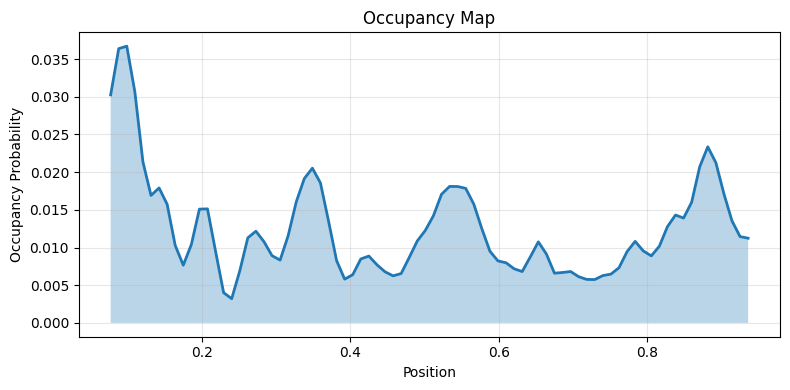

(array([0.03024764, 0.03638169, 0.03670944, 0.03064819, 0.02136356,
        0.01690691, 0.01790174, 0.01573623, 0.01028501, 0.00765253,
        0.01039041, 0.01509245, 0.01512384, 0.00950825, 0.00400265,
        0.00321089, 0.00689596, 0.01128241, 0.01216413, 0.0107726 ,
        0.00891613, 0.00832664, 0.01157616, 0.01605031, 0.01914543,
        0.02052514, 0.01855801, 0.01352181, 0.00826287, 0.00580253,
        0.00639072, 0.00847788, 0.00886455, 0.00771099, 0.00677943,
        0.00623773, 0.00654539, 0.00867495, 0.01086549, 0.01227642,
        0.01421275, 0.0170538 , 0.01810326, 0.0180904 , 0.0178472 ,
        0.01576074, 0.01249776, 0.00950789, 0.00821687, 0.00797301,
        0.00717866, 0.00680839, 0.00873984, 0.01074967, 0.00913621,
        0.00659304, 0.00668591, 0.00681447, 0.00612738, 0.00576451,
        0.00574972, 0.00627782, 0.00646892, 0.00732192, 0.00945713,
        0.01081349, 0.00955397, 0.00888957, 0.01017486, 0.0127662 ,
        0.01430847, 0.01390433, 0.01600053, 0.02

In [96]:
plot_occupancy(
    trajectory_results[trajectory_id]
)

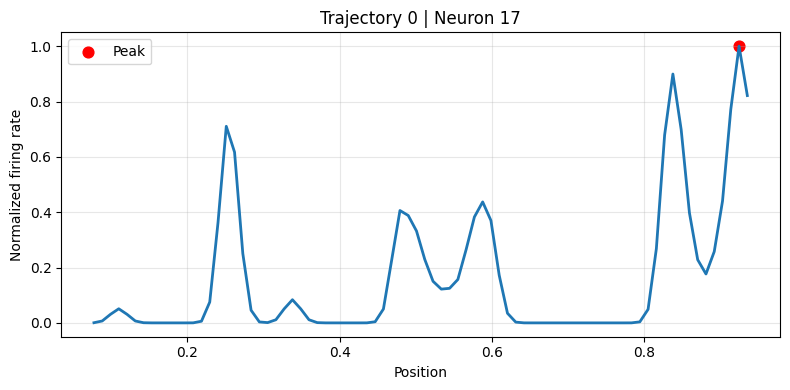

In [97]:
plot_neuron(
    results,
    neuron_id=17,
    trajectory_id=trajectory_id
)

In [98]:
summarize_trajectory(
    results,
    traj_id=0
)

Trajectory 0
Neuron         SI     Sparsity       Peak    Width
------------------------------------------------------------
     0     1.457       0.280     0.153       3
     1     1.436       0.319     0.251       7
     2     1.713       0.244     0.653       7
     3     1.396       0.295     0.468       9
     4     1.706       0.276     0.088      10
     5     1.422       0.338     0.110       9
     6     1.512       0.309     0.382      13
     7     1.716       0.255     0.360       8
     8     1.883       0.215     0.697       8
     9     1.618       0.266     0.729      13
    10     1.880       0.235     0.599      13
    11     1.116       0.382     0.545       9
    12     1.295       0.319     0.295       6
    13     1.178       0.361     0.936       6
    14     1.633       0.245     0.153       5
    15     1.412       0.276     0.697       3
    16     1.277       0.340     0.262       3
    17     1.308       0.317     0.925       8
    18     1.999       0.201 

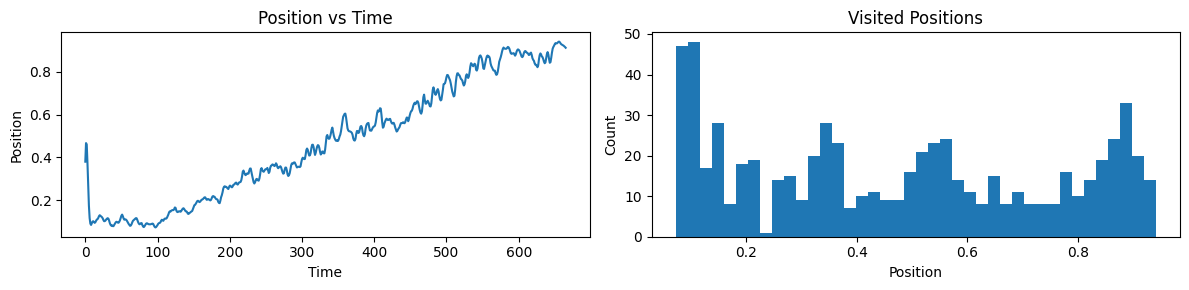

In [99]:
plot_trajectory(
    trajectory_results[trajectory_id]
)

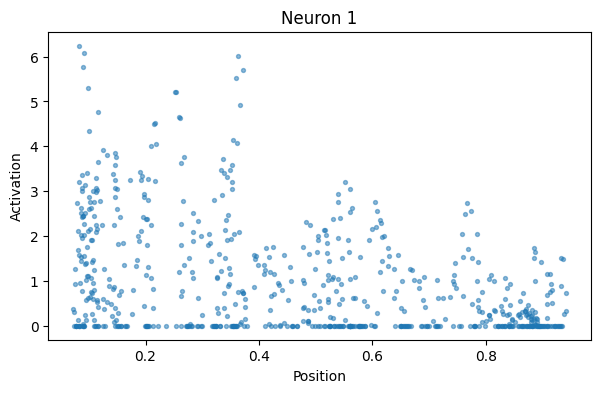

In [100]:
plot_activity_vs_position(
    trajectory_results[trajectory_id],
    layer_name,
    neuron_id=1
)

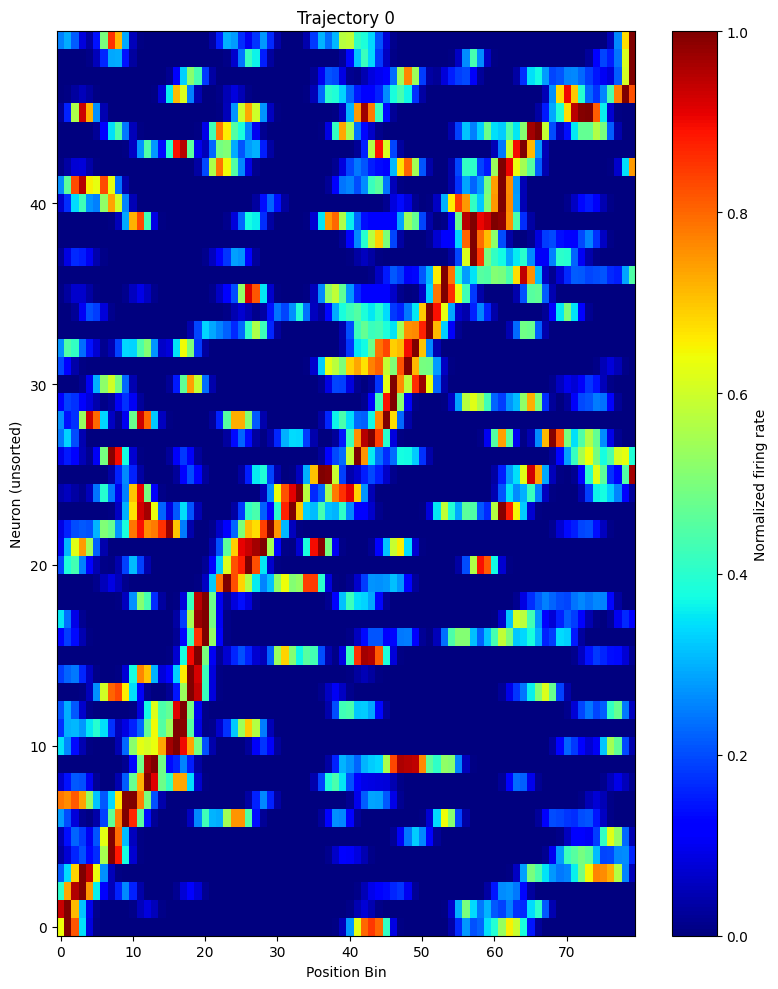

In [101]:
plot_population_place_fields(
    results,
    trajectory_id=trajectory_id
)

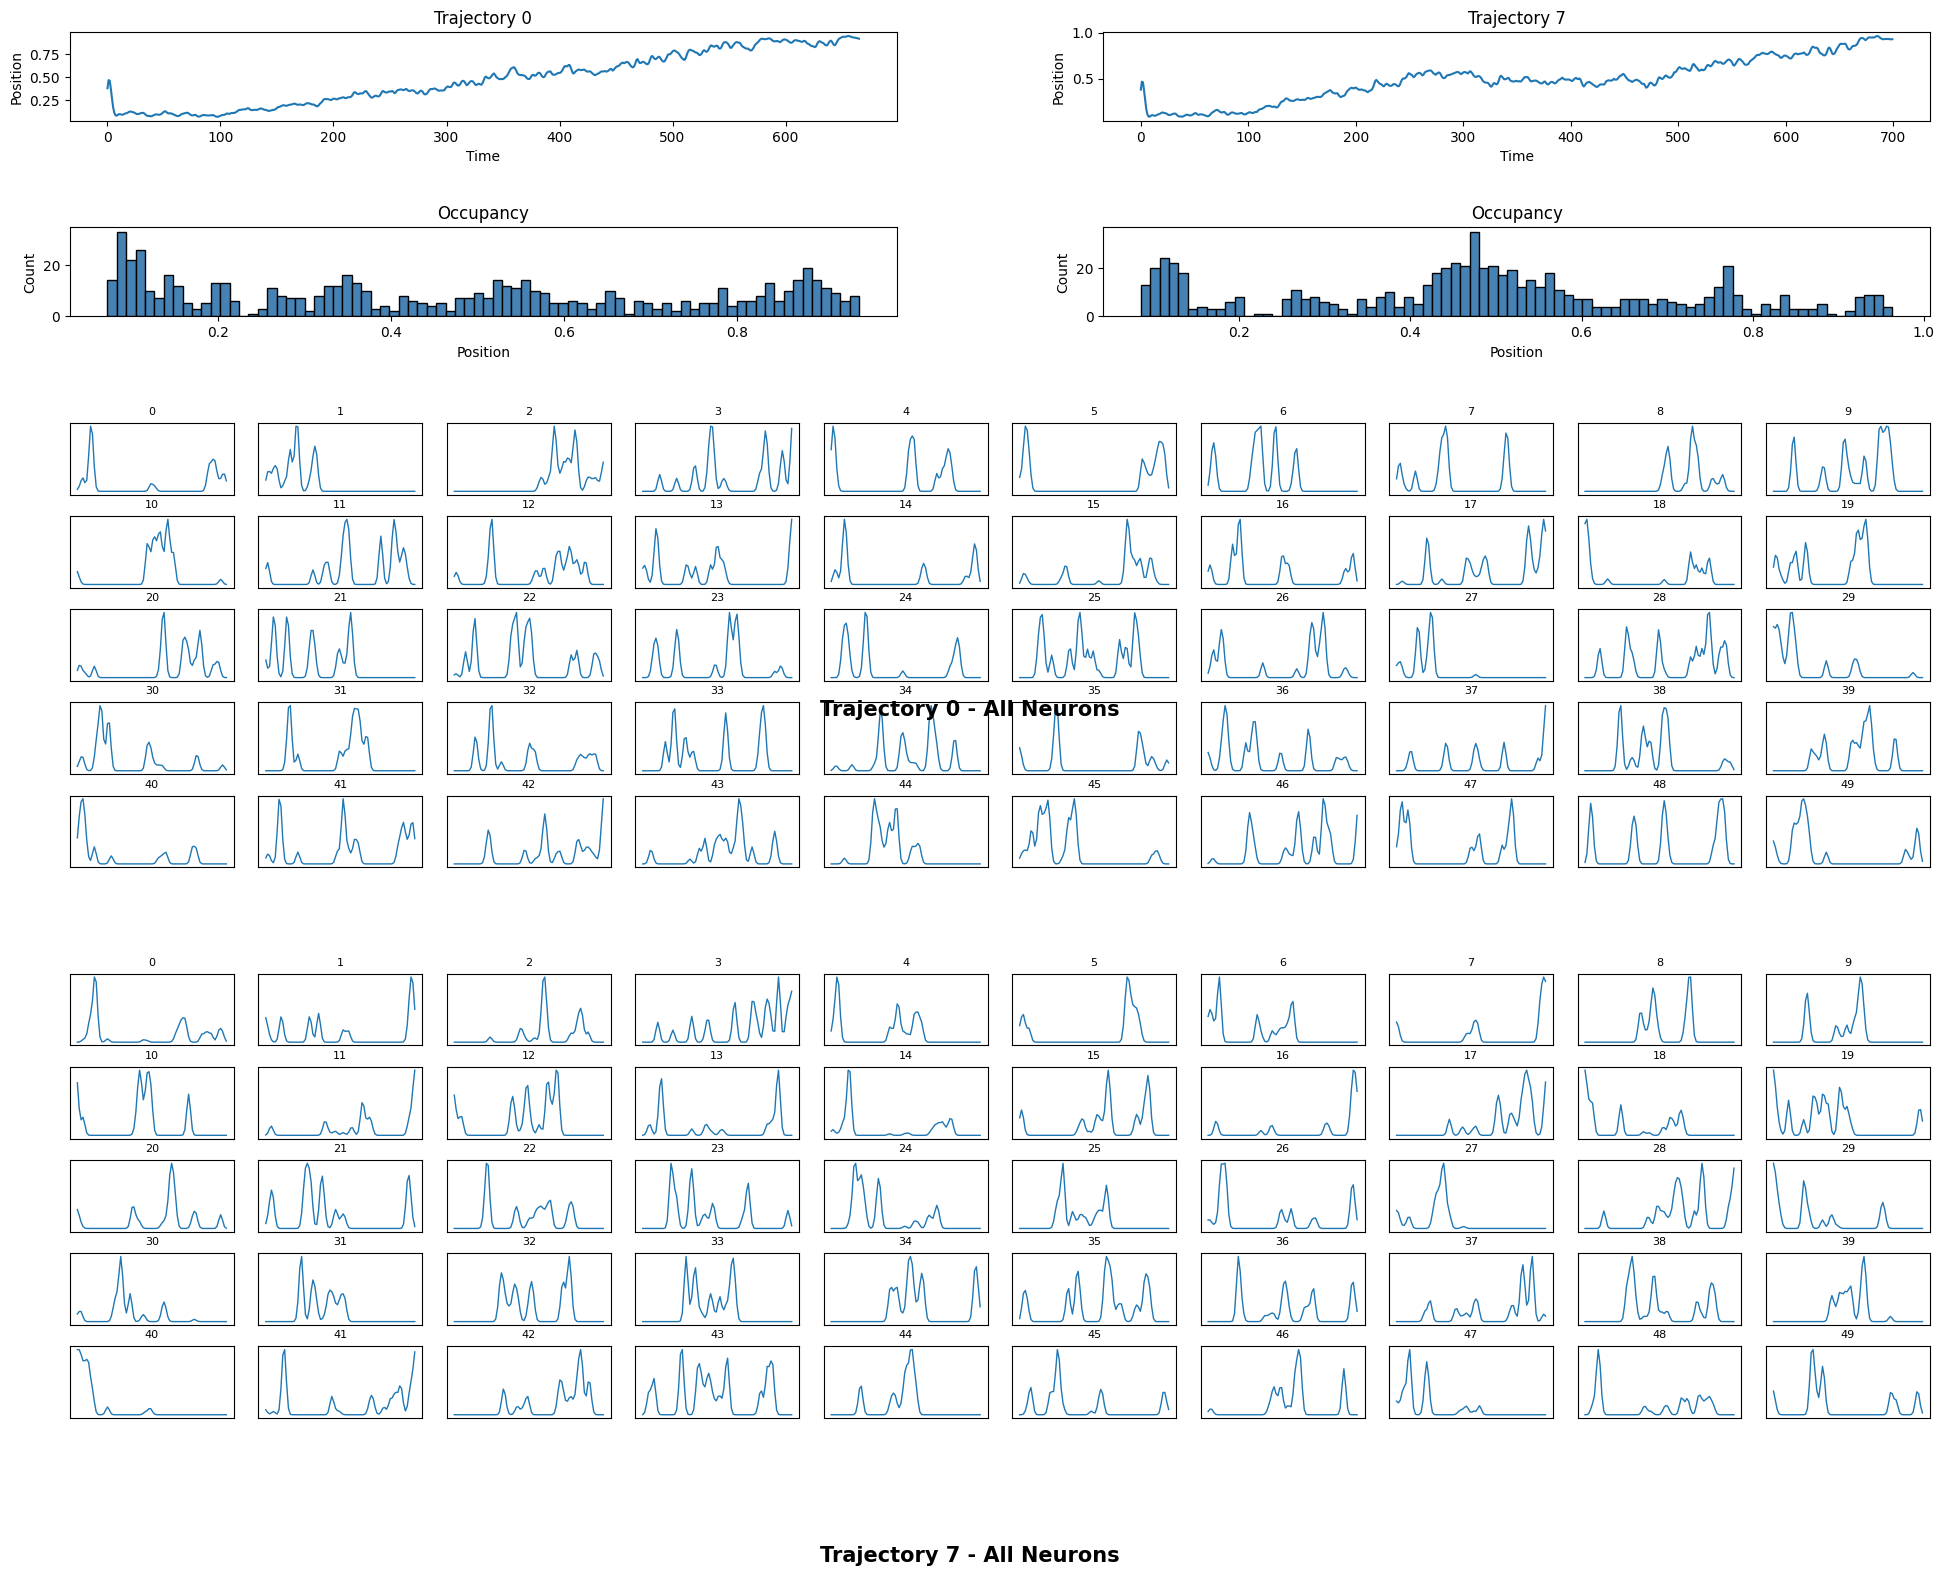

In [55]:
traj1, traj2 = compare_two_random_trajectories(
    trajectory_results,
    results,
    normalize=True,
    seed=42
)

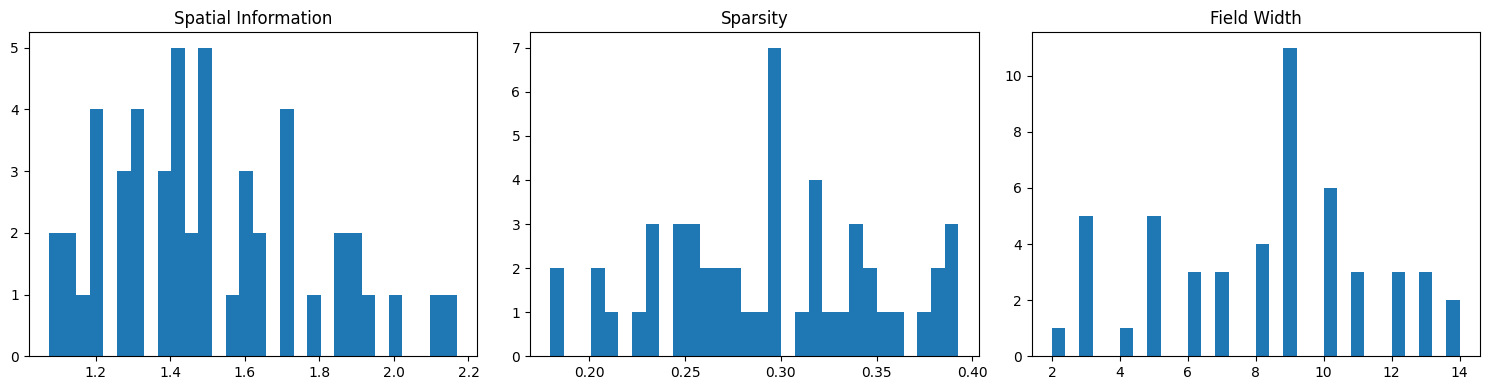

In [56]:
si = results[trajectory_id]["spatial_info"]
sp = results[trajectory_id]["sparsity"]
fw = results[trajectory_id]["field_width"]

fig, ax = plt.subplots(1,3, figsize=(15,4))

ax[0].hist(si, bins=30)
ax[0].set_title("Spatial Information")

ax[1].hist(sp, bins=30)
ax[1].set_title("Sparsity")

ax[2].hist(fw, bins=30)
ax[2].set_title("Field Width")

plt.tight_layout()